## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import neuro_fuzzy_toolbox as nft

## Data

In [2]:
x_train = 2 * torch.rand(200, 2) - 1
x_train

tensor([[-0.7325, -0.8876],
        [-0.2160,  0.2281],
        [-0.4438,  0.1349],
        [ 0.6999,  0.7199],
        [ 0.7260, -0.3182],
        [-0.0513,  0.9455],
        [-0.0767, -0.6301],
        [-0.5561, -0.7732],
        [ 0.2023, -0.4282],
        [ 0.9996, -0.5876],
        [-0.9901,  0.2727],
        [ 0.1104,  0.2438],
        [-0.9509, -0.3537],
        [-0.8621,  0.6107],
        [-0.3521, -0.9039],
        [-0.5469, -0.5744],
        [-0.5338, -0.4721],
        [-0.6972, -0.5691],
        [ 0.2687,  0.1725],
        [-0.3387,  0.5845],
        [ 0.4884,  0.5291],
        [ 0.9933,  0.1252],
        [-0.3727,  0.4345],
        [ 0.2819,  0.5834],
        [ 0.4408, -0.7580],
        [-0.6763, -0.8571],
        [ 0.6682,  0.8117],
        [ 0.0549,  0.7151],
        [ 0.0321,  0.2247],
        [-0.0647, -0.9638],
        [ 0.0366, -0.5224],
        [-0.0795,  0.1900],
        [-0.6851,  0.0452],
        [ 0.9933, -0.8390],
        [ 0.2850,  0.8120],
        [-0.6361,  0

In [3]:
y_train = torch.rand(200)
y_train

tensor([0.5194, 0.9911, 0.3537, 0.2181, 0.7396, 0.9542, 0.1354, 0.7458, 0.2128,
        0.1386, 0.7507, 0.3722, 0.2277, 0.9591, 0.3260, 0.0678, 0.7828, 0.7156,
        0.3107, 0.4714, 0.8166, 0.0421, 0.5646, 0.1515, 0.9538, 0.3998, 0.4551,
        0.0464, 0.0987, 0.8407, 0.9119, 0.1941, 0.1219, 0.4904, 0.8200, 0.0817,
        0.9360, 0.3737, 0.0035, 0.6026, 0.2187, 0.2220, 0.8797, 0.9428, 0.1796,
        0.6587, 0.3740, 0.8158, 0.9118, 0.6471, 0.1208, 0.5347, 0.0695, 0.6833,
        0.2636, 0.7803, 0.1191, 0.5622, 0.0166, 0.7662, 0.7003, 0.2189, 0.5311,
        0.1000, 0.1466, 0.1525, 0.9440, 0.0631, 0.3421, 0.5632, 0.5636, 0.9134,
        0.0267, 0.7945, 0.2405, 0.1926, 0.3336, 0.5861, 0.7834, 0.1708, 0.7990,
        0.8808, 0.7179, 0.2025, 0.7248, 0.9134, 0.4029, 0.8573, 0.3667, 0.8288,
        0.4718, 0.8976, 0.0476, 0.2921, 0.8218, 0.0115, 0.9019, 0.0911, 0.8278,
        0.8050, 0.2872, 0.1585, 0.2491, 0.3866, 0.0264, 0.5783, 0.0152, 0.3433,
        0.6027, 0.9021, 0.1936, 0.7908, 

## Model

In [4]:
model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=8, # 8 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.GeneralizedBell_MF, # Función de membresía gaussiana
    output_type='default', # Tipo de salida: default
)

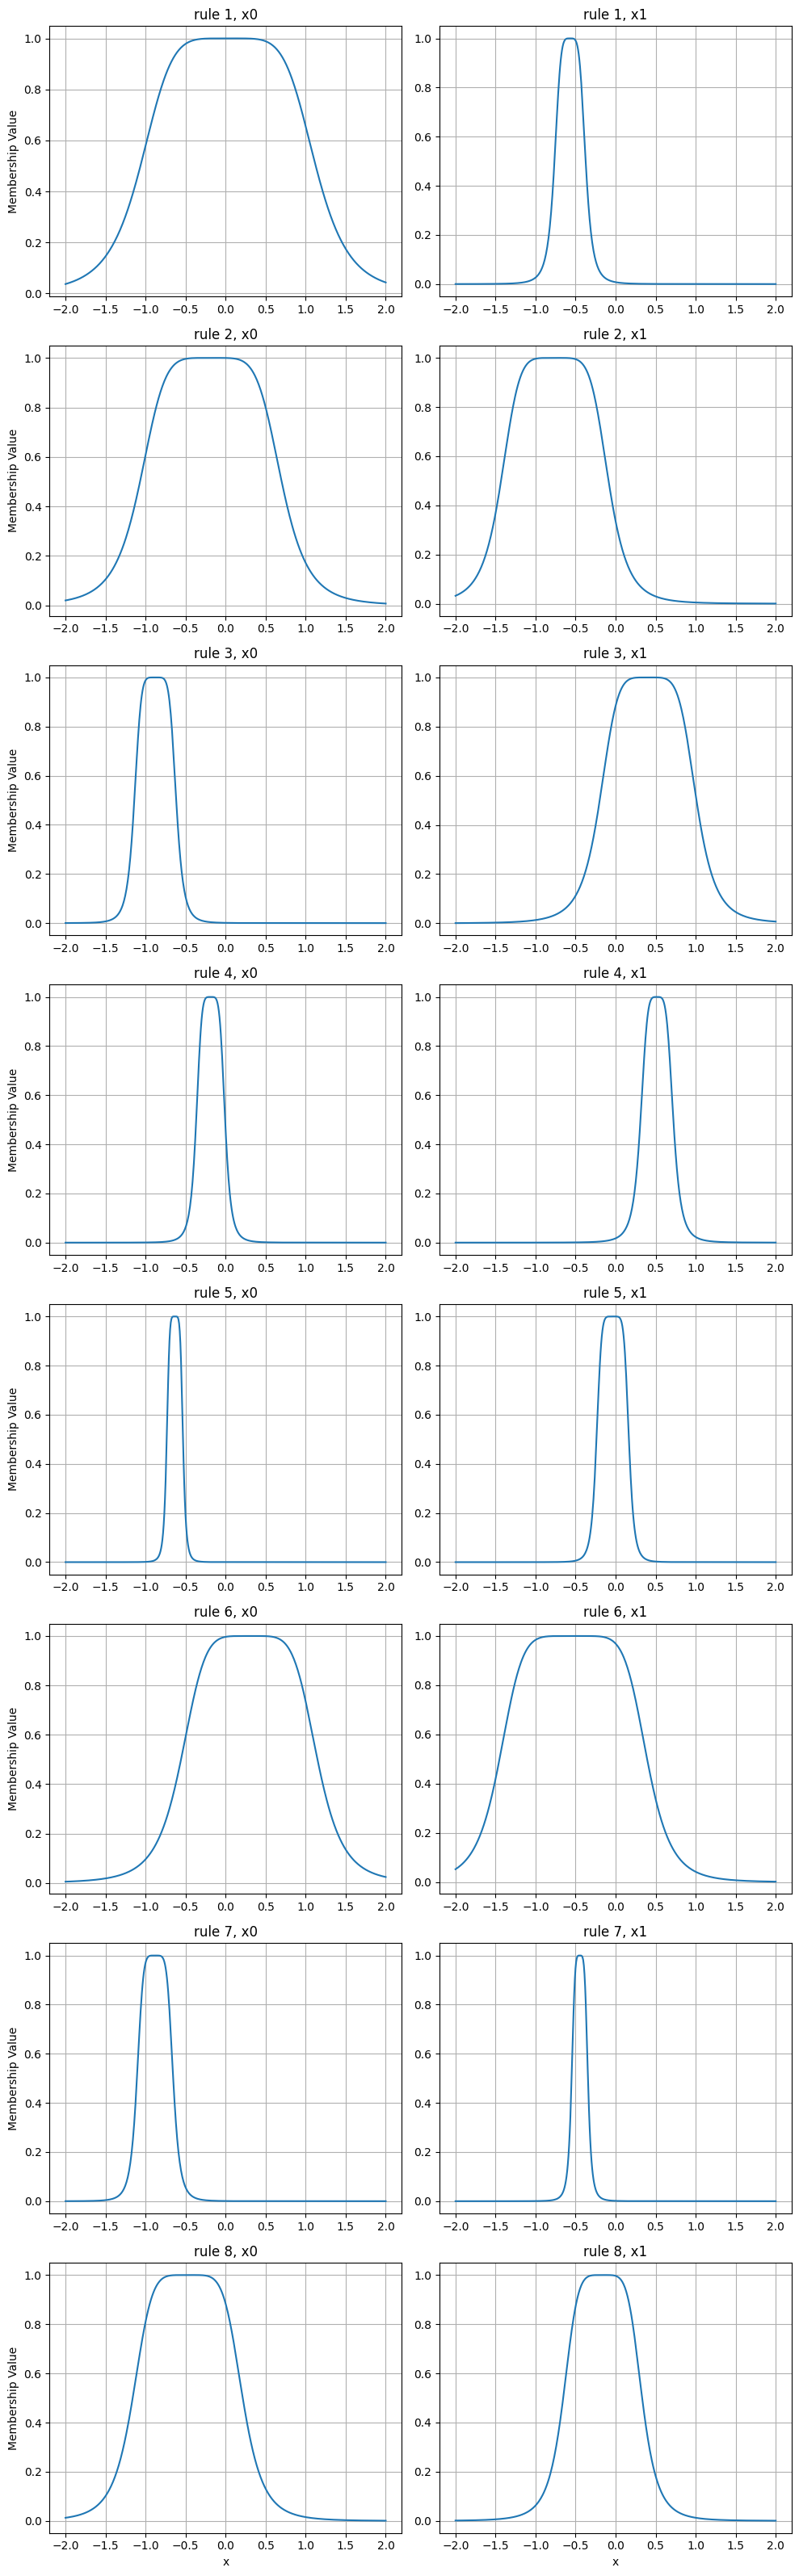

In [5]:
model.plot_premises()

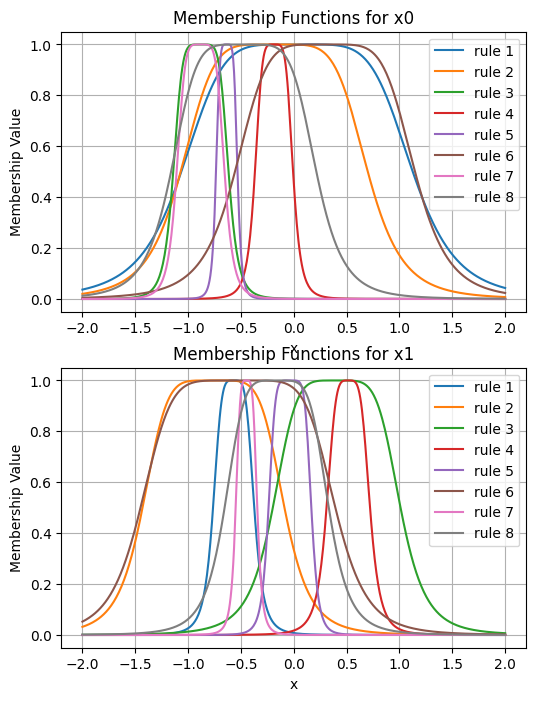

In [6]:
model.plot_premises(group_by_dim=True)

In [7]:
model.get_premises_structure()

x0                            x1                    
               a         b         c         a         b         c
rule 1  1.094863  2.639485  0.030864  0.194916  2.272891 -0.568931
rule 2  0.884833  2.697153 -0.184422  0.671317  2.775086 -0.759492
rule 3  0.261757  2.879177  -0.87882  0.604419  2.555795  0.405961
rule 4  0.180466  2.460925 -0.186991  0.205453  2.189025  0.516074
rule 5   0.10162  2.688822 -0.633895   0.20231  3.085551 -0.036142
rule 6  0.851985   2.68236  0.295279  0.921651  3.089814 -0.528124
rule 7  0.226368  2.713298 -0.881281  0.101962  2.255651 -0.447244
rule 8  0.687308  2.720839  -0.47363  0.492997  2.551664 -0.161615

In [8]:
model.get_premises()

tensor([[[ 1.0949,  2.6395,  0.0309],
         [ 0.8848,  2.6972, -0.1844],
         [ 0.2618,  2.8792, -0.8788],
         [ 0.1805,  2.4609, -0.1870],
         [ 0.1016,  2.6888, -0.6339],
         [ 0.8520,  2.6824,  0.2953],
         [ 0.2264,  2.7133, -0.8813],
         [ 0.6873,  2.7208, -0.4736]],

        [[ 0.1949,  2.2729, -0.5689],
         [ 0.6713,  2.7751, -0.7595],
         [ 0.6044,  2.5558,  0.4060],
         [ 0.2055,  2.1890,  0.5161],
         [ 0.2023,  3.0856, -0.0361],
         [ 0.9217,  3.0898, -0.5281],
         [ 0.1020,  2.2557, -0.4472],
         [ 0.4930,  2.5517, -0.1616]]])

In [9]:
model.get_consequents_structure()[0]

,x0,x1,
,c0,c1,c2
rule 1,0.209372,-0.529802,-0.690108
rule 2,-0.952603,-0.753431,0.634770
rule 3,-0.714239,0.684746,0.933146
rule 4,0.940419,0.274192,0.742298
rule 5,-0.131298,-0.358009,0.411432
rule 6,-0.025113,-0.113431,-0.503794
rule 7,-0.991370,-0.213160,-0.454932
rule 8,-0.763789,0.673600,0.081326


In [10]:
model.init_consequents(x_train, y_train)

In [11]:
model.get_consequents_structure()[0]

,x0,x1,
,c0,c1,c2
rule 1,-0.334923,-0.040477,-0.052786
rule 2,1.251151,-0.573497,0.702006
rule 3,-2.405153,1.076706,-2.129486
rule 4,-1.493996,0.550146,-0.118691
rule 5,-22.454813,-16.133125,-13.703074
rule 6,-0.467735,0.205712,0.641891
rule 7,6.249293,-24.777050,-3.110964
rule 8,-0.925036,0.327055,0.166583


In [12]:
model.get_rules_structure()

premises                                                    \
              x0                            x1                       
               a         b         c         a         b         c   
rule 1  1.094863  2.639485  0.030864  0.194916  2.272891 -0.568931   
rule 2  0.884833  2.697153 -0.184422  0.671317  2.775086 -0.759492   
rule 3  0.261757  2.879177  -0.87882  0.604419  2.555795  0.405961   
rule 4  0.180466  2.460925 -0.186991  0.205453  2.189025  0.516074   
rule 5   0.10162  2.688822 -0.633895   0.20231  3.085551 -0.036142   
rule 6  0.851985   2.68236  0.295279  0.921651  3.089814 -0.528124   
rule 7  0.226368  2.713298 -0.881281  0.101962  2.255651 -0.447244   
rule 8  0.687308  2.720839  -0.47363  0.492997  2.551664 -0.161615   

       output 1 consequents                        
                         x0         x1             
                         c0         c1         c2  
rule 1            -0.334923  -0.040477  -0.052786  
rule 2             1.251151  -0.573497   0.702006  
rule 3            -2.405153   1.076706  -2.129486  
rule 4            -1.493996   0.550146  -0.118691  
rule 5           -22.454813 -16.133125 -13.703074  
rule 6            -0.467735   0.205712   0.641891  
rule 7             6.249293 -24.777050  -3.110964  
rule 8            -0.925036   0.327055   0.166583

In [13]:
model(x_train[:10])

tensor([0.3990, 0.5570, 0.5218, 0.4772, 0.5380, 0.6420, 0.4330, 0.4563, 0.4445,
        0.1172], grad_fn=<SqueezeBackward1>)

In [14]:
with torch.no_grad():
    output = model(x_train[:10])

print(output)

tensor([0.3990, 0.5570, 0.5218, 0.4772, 0.5380, 0.6420, 0.4330, 0.4563, 0.4445,
        0.1172])


In [15]:
model.predict(x_train[:10])

tensor([0.3990, 0.5570, 0.5218, 0.4772, 0.5380, 0.6420, 0.4330, 0.4563, 0.4445,
        0.1172])

## Binary output

In [16]:
x_train = 2 * torch.rand(200, 3) - 1

In [17]:
y_train = torch.randint(0, 2, (200,))
y_train[:10]

tensor([0, 0, 0, 0, 1, 1, 1, 1, 1, 0])

In [18]:
bin_model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=10, # 10 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='sigmoid', # Tipo de salida: capa sigmoide
)

In [19]:
bin_model.predict(x_train[:10])

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [20]:
bin_model(x_train[:10])

tensor([0.5778, 0.6006, 0.6079, 0.5271, 0.6603, 0.5455, 0.5993, 0.6117, 0.5374,
        0.5114], grad_fn=<SigmoidBackward0>)

## Multiclass output

In [21]:
x_train = 2 * torch.rand(200, 3) - 1

In [22]:
y_train = torch.randint(0, 4, (200,))
y_train[:10]

tensor([3, 3, 2, 3, 1, 1, 0, 0, 2, 2])

In [23]:
mul_class_model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=15, # 3 funciones de membresía
    outputs=4, # 4 clases
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: capa softmax
)

In [24]:
mul_class_model.predict(x_train[:10])

tensor([3, 2, 3, 0, 1, 1, 3, 3, 3, 3])

In [25]:
mul_class_model(x_train[:10])

tensor([[-0.1900,  0.2104, -0.2737,  0.8283],
        [-0.2653, -0.4074,  0.1331, -0.3415],
        [-0.4043, -0.4356, -0.2233, -0.2188],
        [-0.1990, -0.7977, -0.6289, -0.2053],
        [-0.1826,  0.2835, -0.4522,  0.0438],
        [ 0.1055,  0.4832, -0.4699,  0.3989],
        [-0.6923, -0.4222, -1.2421, -0.1303],
        [-0.3358, -0.1692, -0.2086,  0.3533],
        [-0.3563, -0.0114, -0.2088,  0.0669],
        [ 0.2626,  0.8182, -0.0518,  1.2234]], grad_fn=<SqueezeBackward1>)

In [26]:
mul_class_model(x_train[:10], return_probs=True)

tensor([[0.1618, 0.2415, 0.1488, 0.4479],
        [0.2334, 0.2025, 0.3477, 0.2163],
        [0.2288, 0.2217, 0.2741, 0.2754],
        [0.3131, 0.1721, 0.2037, 0.3111],
        [0.2169, 0.3456, 0.1656, 0.2719],
        [0.2292, 0.3344, 0.1289, 0.3074],
        [0.2155, 0.2823, 0.1243, 0.3779],
        [0.1884, 0.2225, 0.2139, 0.3752],
        [0.1962, 0.2770, 0.2273, 0.2995],
        [0.1643, 0.2864, 0.1200, 0.4294]], grad_fn=<SoftmaxBackward0>)

In [27]:
print(mul_class_model.get_rules_structure().to_string())

         premises                                                   output 1 consequents                               output 2 consequents                               output 3 consequents                               output 4 consequents                              
               x0                  x1                  x2                             x0        x1        x2                             x0        x1        x2                             x0        x1        x2                             x0        x1        x2          
               mu     sigma        mu     sigma        mu     sigma                   c0        c1        c2        c3                   c0        c1        c2        c3                   c0        c1        c2        c3                   c0        c1        c2        c3
rule 1   0.216366    0.3206 -0.100952  0.406079  0.419299  0.944518             0.191965 -0.326331 -0.317228 -0.656044             0.950127 -0.814350  0.656325 -0.107998             0.

## Multiple outputs

In [28]:
x_train = 2 * torch.rand(200, 2) - 1

In [29]:
model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=9, # 9 funciones de membresía
    outputs=2, # 2 salidas
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='default', # Tipo de salida: default
)

In [30]:
model.get_consequents_structure()

[              x0        x1          
               c0        c1        c2
 rule 1 -0.762877 -0.602374  0.546774
 rule 2  0.277029  0.526866 -0.810103
 rule 3 -0.254166 -0.028645 -0.148093
 rule 4  0.707089 -0.830521 -0.618266
 rule 5  0.085902  0.080994 -0.487784
 rule 6 -0.575419 -0.376657 -0.476235
 rule 7  0.856126 -0.472064  0.584261
 rule 8  0.529054  0.554680 -0.739666
 rule 9 -0.989766  0.692832  0.910470,
               x0        x1          
               c0        c1        c2
 rule 1 -0.425145 -0.718345  0.432130
 rule 2  0.553101 -0.281935 -0.876340
 rule 3  0.547103  0.382792 -0.725601
 rule 4 -0.645175  0.051002  0.354157
 rule 5 -0.767141 -0.000897  0.483989
 rule 6  0.198779 -0.495708  0.434122
 rule 7 -0.831121 -0.591483 -0.013894
 rule 8  0.061682 -0.155323 -0.730310
 rule 9  0.579275 -0.997946 -0.128708]

In [31]:
model(x_train[:10])

tensor([[ 0.0744,  0.0015],
        [-0.3256, -0.3458],
        [-0.2026,  0.3300],
        [-0.2910, -0.1573],
        [-0.2149,  0.2592],
        [-0.2374, -0.3067],
        [-0.3227, -0.3445],
        [-0.2194, -0.0486],
        [-0.2497, -0.1052],
        [-0.4084, -0.0885]], grad_fn=<SqueezeBackward1>)

## Multiclass problem

In [32]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=6, # 6 funciones de membresía
    outputs=3, # 3 salidas
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: capa softmax
)

In [33]:
model(x_train[:10])

tensor([[-0.3398, -0.5479, -1.3866],
        [-0.7345, -0.5840, -0.4331],
        [-0.8594, -0.0219, -0.1569],
        [-0.9325, -0.5508, -0.5126],
        [-0.9054,  0.0287, -0.1492],
        [-0.6539,  0.3863, -0.1037],
        [-0.5129, -0.1662, -1.1378],
        [-0.9037,  0.6091,  0.0987],
        [-0.6209, -0.6386, -0.7510],
        [-0.3202, -0.3976, -1.5805]], grad_fn=<SqueezeBackward1>)

In [34]:
model(x_train[:10], return_probs=True)

tensor([[0.4623, 0.3754, 0.1623],
        [0.2846, 0.3308, 0.3846],
        [0.1876, 0.4336, 0.3788],
        [0.2508, 0.3674, 0.3817],
        [0.1762, 0.4485, 0.3753],
        [0.1797, 0.5086, 0.3116],
        [0.3390, 0.4795, 0.1815],
        [0.1210, 0.5493, 0.3297],
        [0.3496, 0.3435, 0.3069],
        [0.4527, 0.4190, 0.1284]], grad_fn=<SoftmaxBackward0>)

In [35]:
model.predict(x_train[:10])

tensor([0, 2, 1, 2, 1, 1, 1, 1, 0, 0])